<a href="https://colab.research.google.com/github/javierraneros-cell/UD2-Mineria-de-Datos---Colab-/blob/main/Practica_UD2_ATLETAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANALISIS DE COMPONENTES PRINCIPALES - UD2 MINERIA DE DATOS E IA CORPORTATIVA**

## INTRODUCCIÓN

En esta actividad se va a trabajar con conjunto de datos que contiene las marcas de los alumnos de un centro de alto rendimiento en diferentes pruebas atléticas. Concretamente, los campos que se recogen son los siguientes:

grupo clase a la que pertenece cada alumno (A o B)

*   100m lisos: marca en la prueba de 100 metros lisos
*   400m lisos: marca en la prueba de 400 metros lisos
*   100m vallas: marca en la prueba de 100 metros vallas
*   1500m lisos: marca en la prueba de 1500 metros lisos
*   salto horizontal: marca en el salto de longitud
*   lanzamiento de peso: marca en lanzamiento de peso o de bala (bola de acero)
*   salto de altura: marca en el salto vertical de altura
*   disco: marca en lanzamiento de disco
*   pértiga: marca en salto con pértiga
*   jabalina: marca en lanzamiento de jabalina

El objetivo final es calcular una única medida que permita determinar el rendimiento de cada alumno. Como se tratan de diferentes pruebas medidas en diferentes unidades, resulta complicado encontrar la forma de resumir los resultados en un único valor numérico. Para esta tarea se va a utilizar el análisis de componentes principales que permite reducir el número de dimensiones manteniendo la mayor cantidad de información posible. Concretamente, se desea reducir el número de dimensiones a 1.


# **PROBLEMA 1: PREPARACIÓN DE LOS DATOS**

## Importacion de ficheros CSV

Para esta tarea se facilitan 4 ficheros separadaos con marcas de pruebas de atletismo para dos grupos de atletas y en 2 días diferentes, por lo que habrá que unir o concatenar los ficheros en un único Dataset.

Los 4 ficheros CSV se encuentran en Google Drive al mismo nivel que el cuaderno Colab Notebook en la carpeta /datos, por lo que se procede a su carga en la carpeta csv del proyecto.

In [1]:
# Instalar gdown si no está instalado
!pip install gdown

Para incorporar el fichero de Google Drive al proyecto hay que descargarlo con **gdown** y guaradarlos como ficheros CSV para despues ser usados en la creación del/los Datasets.

El listado de ficheros que se encuentran en la carpeta /datos https://drive.google.com/drive/folders/1jvkkCQLWtOoHM3Pe2p0zwleyWeXLnpYG es:

*   grupoA_primer_dia.csv 	--> 17qFwj7BbK7zcqDY_tIVkiqRQt7lIenD0
*   grupoA_segundo_dia.csv 	--> 1MZKjVE61nWtB8BbBz7xNFLPjrtK2ITmU
*   grupoB_primer_dia.csv		--> 1R6GKBa3KrlVtzPelqSXlqeEbD_33Trkd
*   grupoB_segundo_dia.csv	--> 1jvkkCQLWtOoHM3Pe2p0zwleyWeXLnpYG

In [2]:
import gdown

#IDs de los archivos a descargar de Google Drive que tienen que estar compartidos
# grupoA_primer_dia.csv 	--> 17qFwj7BbK7zcqDY_tIVkiqRQt7lIenD0
# grupoA_segundo_dia.csv 	--> 1MZKjVE61nWtB8BbBz7xNFLPjrtK2ITmU
# grupoB_primer_dia.csv		--> 1R6GKBa3KrlVtzPelqSXlqeEbD_33Trkd
# grupoB_segundo_dia.csv	--> 1ZFtBr0l30FKz7qyzaMMb6W74Lky6IDlv

file_grupoA_primer_dia_id = '17qFwj7BbK7zcqDY_tIVkiqRQt7lIenD0'
file_grupoA_segundo_dia_dia_id = '1MZKjVE61nWtB8BbBz7xNFLPjrtK2ITmU'
file_grupoB_primer_dia_id = '1R6GKBa3KrlVtzPelqSXlqeEbD_33Trkd'
file_grupoB_segundo_dia_id = '1ZFtBr0l30FKz7qyzaMMb6W74Lky6IDlv'

output_grupoA_primer_dia = 'grupoA_primer_dia.csv'
output_grupoA_segundo_dia = 'grupoA_segundo_dia.csv'
output_grupoB_primer_dia = 'grupoB_primer_dia.csv'
output_grupoB_segundo_dia = 'grupoB_segundo_dia.csv'

#GRUPO A
#Primer dia
url = f'https://drive.google.com/uc?id={file_grupoA_primer_dia_id}'
gdown.download(url, output_grupoA_primer_dia, quiet=False)
print('\nPrimer dia GRUPO A descargado...')
#Segundo dia
url = f'https://drive.google.com/uc?id={file_grupoA_segundo_dia_dia_id}'
gdown.download(url, output_grupoA_segundo_dia, quiet=False)
print('\nSegundo dia GRUPO A descargado...')
#GRUPO B
#Primer dia
url = f'https://drive.google.com/uc?id={file_grupoB_primer_dia_id}'
gdown.download(url, output_grupoB_primer_dia, quiet=False)
print('\nPrimer dia GRUPO B descargado...')
#Segundo dia
url = f'https://drive.google.com/uc?id={file_grupoB_segundo_dia_id}'
gdown.download(url, output_grupoB_segundo_dia, quiet=False)
print('\nSegundo dia GRUPO B descargado...')


Downloading...
From: https://drive.google.com/uc?id=17qFwj7BbK7zcqDY_tIVkiqRQt7lIenD0
To: /content/grupoA_primer_dia.csv
100%|██████████| 496/496 [00:00<00:00, 73.6kB/s]



Primer dia GRUPO A descargado...


Downloading...
From: https://drive.google.com/uc?id=1MZKjVE61nWtB8BbBz7xNFLPjrtK2ITmU
To: /content/grupoA_segundo_dia.csv
100%|██████████| 633/633 [00:00<00:00, 1.49MB/s]



Segundo dia GRUPO A descargado...


Downloading...
From: https://drive.google.com/uc?id=1R6GKBa3KrlVtzPelqSXlqeEbD_33Trkd
To: /content/grupoB_primer_dia.csv
100%|██████████| 1.02k/1.02k [00:00<00:00, 2.84MB/s]



Primer dia GRUPO B descargado...


Downloading...
From: https://drive.google.com/uc?id=1ZFtBr0l30FKz7qyzaMMb6W74Lky6IDlv
To: /content/grupoB_segundo_dia.csv
100%|██████████| 1.24k/1.24k [00:00<00:00, 4.53MB/s]


Segundo dia GRUPO B descargado...


## Creación Datasets

Tenemos que unir los 4 ficheros en una única fuente de datos. Para ello lo que vamos a hacer es crear 4 Datasets por cada ficheros csv y despues los concatenaremos.



In [3]:
import pandas as pd

#Creación de 4 Datasets y mostramos los datos
df_grupoA_primer_dia = pd.read_csv(output_grupoA_primer_dia)
print(f"Archivo '{output_grupoA_primer_dia}' descargado y cargado exitosamente.")
display(df_grupoA_primer_dia.head())

df_grupoA_segundo_dia = pd.read_csv(output_grupoA_segundo_dia)
print(f"\nArchivo '{output_grupoA_segundo_dia}' descargado y cargado exitosamente.")
display(df_grupoA_segundo_dia.head())

df_grupoB_primer_dia = pd.read_csv(output_grupoB_primer_dia)
print(f"\nArchivo '{output_grupoB_primer_dia}' descargado y cargado exitosamente.")
display(df_grupoB_primer_dia.head())

df_grupoB_segundo_dia = pd.read_csv(output_grupoB_segundo_dia)
print(f"\nArchivo '{output_grupoB_segundo_dia}' descargado y cargado exitosamente.")
display(df_grupoB_segundo_dia.head())




Archivo 'grupoA_primer_dia.csv' descargado y cargado exitosamente.


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos
0,Torres,A,11.04,49.81,14.69,291.7
1,Delgado,A,10.76,49.37,14.05,301.5
2,Ramírez,A,11.02,48.37,14.09,300.2
3,Díaz,A,11.02,48.93,-14.99,280.1
4,Sánchez,A,11.34,50.42,15.31,276.4



Archivo 'grupoA_segundo_dia.csv' descargado y cargado exitosamente.


,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,7.09,15.19,2.10,46.26,4.72,NaN



Archivo 'grupoB_primer_dia.csv' descargado y cargado exitosamente.


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos
0,Silva,B,10.85,48.36,14.05,280.01
1,González,B,10.44,49.19,14.13,282.00
2,Herrera,B,10.50,46.81,13.97,278.11
3,Guzmán,B,10.89,48.97,14.56,265.42
4,Ríos,B,10.62,47.97,14.01,NaN



Archivo 'grupoB_segundo_dia.csv' descargado y cargado exitosamente.


,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Silva,B,7.84,16.36,2.12,48.72,5.0,70.52
1,González,B,7.96,15.23,2.06,50.11,4.9,69.71
2,Herrera,B,7.81,15.93,2.09,51.65,4.6,55.54
3,Guzmán,B,7.47,15.73,2.15,48.34,4.4,58.46
4,Ríos,B,7.74,14.48,1.97,43.73,4.9,55.39


## CONCATENACION - Integración de los datos

La integración de los 4 Datasets se realizara con la concatenación se realizaría primero uniendo a los grupos A y B de cada dia con una concatenación por FILAS y despues concatenaremos por COLUMNAS para unir todos los registros del primer dia con todos los registros del segundo dia:


> **Concatenacion x FILAS**:
>
>     grupoA_primer_dia + grupoB_primer_dia   --> primer_dia
>
>     grupoA_segundo_dia + grupoB_segundo_dia --> segundo_dia

Para concatenar se usa el método **concat** de Pandas **axis=0** para concatenar por filas y **axis=1** para unir por columnas
```
# concat([dataset1, dataset2], axis= 0 )
```

> **Concatenacion x COLUMNAS**:
>
>     primer_dia +  segundo_dia

```
# concat([dataset1, dataset2], axis= 1 )
```






In [4]:
#Concatenación x FILAS - Dataset primer dia y Segundo dia
df_result_primer_dia = pd.concat([df_grupoA_primer_dia, df_grupoB_primer_dia], axis=0, ignore_index=True)
print(f"\nConcatenacion creada correctamente para df_result_primer_dia ...\n")
display(df_result_primer_dia.head())
display(df_result_primer_dia.tail())

df_result_segundo_dia = pd.concat([df_grupoA_segundo_dia, df_grupoB_segundo_dia], axis=0, ignore_index=True)
print(f"\nConcatenacion creada correctamente para df_result_segundo_dia ...\n")
display(df_result_segundo_dia.head())
display(df_result_segundo_dia.tail())


Concatenacion creada correctamente para df_result_primer_dia ...



,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos
0,Torres,A,11.04,49.81,14.69,291.7
1,Delgado,A,10.76,49.37,14.05,301.5
2,Ramírez,A,11.02,48.37,14.09,300.2
3,Díaz,A,11.02,48.93,-14.99,280.1
4,Sánchez,A,11.34,50.42,15.31,276.4


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos
36,Figueroa,B,11.10,49.34,15.38,263.08
37,Aguilar,B,11.33,50.54,14.98,278.67
38,Montes,B,10.86,51.16,14.96,317.00
39,Morales,B,11.23,50.95,15.09,281.70
40,Jiménez,B,11.36,53.20,15.39,296.12



Concatenacion creada correctamente para df_result_segundo_dia ...



,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,7.09,15.19,2.10,46.26,4.72,NaN


,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
36,Figueroa,B,7.03,13.22,1.85,40.22,4.5,58.36
37,Aguilar,B,7.26,13.30,1.97,43.34,4.5,52.92
38,Montes,B,7.07,14.81,1.94,46.07,4.7,53.05
39,Morales,B,6.99,13.53,1.85,NaN,4.5,60.00
40,Jiménez,B,6.68,14.92,1.94,48.66,4.4,58.62


In [5]:
#Concatenacion x COLUMNAS
df_dataset = pd.concat([df_result_primer_dia, df_result_segundo_dia], axis=1)
print(f"\nConcatenacion creada correctamente para df_dataset ...\n")
display(df_dataset.head())
display(df_dataset.tail())


Concatenacion creada correctamente para df_dataset ...



,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.7,Torres,A,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.5,Delgado,A,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.2,Ramírez,A,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,-14.99,280.1,Díaz,A,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.4,Sánchez,A,7.09,15.19,2.10,46.26,4.72,NaN


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,alumno,grupo,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
36,Figueroa,B,11.10,49.34,15.38,263.08,Figueroa,B,7.03,13.22,1.85,40.22,4.5,58.36
37,Aguilar,B,11.33,50.54,14.98,278.67,Aguilar,B,7.26,13.30,1.97,43.34,4.5,52.92
38,Montes,B,10.86,51.16,14.96,317.00,Montes,B,7.07,14.81,1.94,46.07,4.7,53.05
39,Morales,B,11.23,50.95,15.09,281.70,Morales,B,6.99,13.53,1.85,NaN,4.5,60.00
40,Jiménez,B,11.36,53.20,15.39,296.12,Jiménez,B,6.68,14.92,1.94,48.66,4.4,58.62


In [6]:
# Antes de eliminar, comprobamos que las posiciones 6 y 7 son de columnas duplicadas tras hacer la concatenación
print("Nombres de las columnas antes de eliminar:")
print(df_dataset.columns.tolist())

# df.drop() elimina todas las columnas con el nombre especificado.
# Para eliminar SOLO las columnas en las posiciones 6 y 7, seleccionaremos explícitamente las columnas que queremos mantener.

# Creamos una lista de índices de columnas que queremos mantener:
# Queremos mantener las columnas desde el índice 0 hasta el 5 (inclusive)
# y las columnas desde el índice 8 hasta el final.
columns_to_keep_indices = list(range(6)) + list(range(8, len(df_dataset.columns)))

# Seleccionar estas columnas para crear el nuevo DataSet limpio,
# seleccionando con ILOC porque por nombre no podríamos referenciarlas al estar duplicadas:
df_dataset = df_dataset.iloc[:, columns_to_keep_indices]

print("\nDataSet después de eliminar las columnas duplicadas por índice:")
display(df_dataset.head())
display(df_dataset.tail())
print(f"El DataSet ahora tiene {df_dataset.shape[1]} columnas.")
print("Nombres de las columnas después de eliminar:")
print(df_dataset.columns.tolist())

Nombres de las columnas antes de eliminar:
['alumno', 'grupo', '100m lisos', '400m lisos', '100m vallas', '1500m lisos', 'alumno', 'grupo', 'salto horizontal', 'lanzamiento de peso', 'salto de altura', 'disco', 'pértiga', 'jabalina']

DataSet después de eliminar las columnas duplicadas por índice:


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.7,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.5,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.2,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,-14.99,280.1,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.4,7.09,15.19,2.10,46.26,4.72,NaN


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
36,Figueroa,B,11.10,49.34,15.38,263.08,7.03,13.22,1.85,40.22,4.5,58.36
37,Aguilar,B,11.33,50.54,14.98,278.67,7.26,13.30,1.97,43.34,4.5,52.92
38,Montes,B,10.86,51.16,14.96,317.00,7.07,14.81,1.94,46.07,4.7,53.05
39,Morales,B,11.23,50.95,15.09,281.70,6.99,13.53,1.85,NaN,4.5,60.00
40,Jiménez,B,11.36,53.20,15.39,296.12,6.68,14.92,1.94,48.66,4.4,58.62


El DataSet ahora tiene 12 columnas.
Nombres de las columnas después de eliminar:
['alumno', 'grupo', '100m lisos', '400m lisos', '100m vallas', '1500m lisos', 'salto horizontal', 'lanzamiento de peso', 'salto de altura', 'disco', 'pértiga', 'jabalina']


Consultamos los datos en formato tabla para comprobar los datos finales cargados y hacer un análisis visual de los datos con los filtros que podemos disponer, como es el caso de los nulo y los negativos como se indica en la tarea en el punto 2

In [7]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

print("Mostrando el DataSet df_dataset como una tabla interactiva mediante enable_dataframe_formatter_formatter:")
df_dataset

Mostrando el DataSet df_dataset como una tabla interactiva mediante enable_dataframe_formatter_formatter:


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.70,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.50,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.20,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,-14.99,280.10,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.40,7.09,15.19,2.10,46.26,4.72,NaN
5,Miranda,A,11.11,48.68,14.23,278.10,7.60,14.31,1.98,41.10,4.92,51.77
6,Rodríguez,A,11.13,48.62,14.17,268.00,7.30,13.48,2.01,45.67,4.42,55.37
7,Vargas,A,10.83,49.91,14.38,285.10,7.31,13.76,2.13,44.41,4.42,-56.37
8,Castro,A,11.64,50.14,14.93,262.10,6.81,14.57,1.95,47.60,4.92,52.33
9,Pérez,A,11.37,51.10,15.06,285.10,7.56,14.41,1.86,44.99,4.82,57.19


## FILTRAR VALORES NEGATIVOS

Despues de hacer el analisis visual, vemos que hay valores negativos en 100m lisos, 400m lisos, 100m vallas, lanzamiento de peso, salto de altura, pertiga y jabalina, pero vamos a identificar exactamente las columnas numéricas que representan marcas atléticas y las cambiaremos a valor positivo porque es un error de carga.

In [8]:
import numpy as np

# Identificar las columnas numéricas relevantes para filtrar valores negativos
# Excluyendo 'alumno' y 'grupo' que son identificadores o categóricas
performance_columns = [
    '100m lisos', '400m lisos', '100m vallas', '1500m lisos',
    'salto horizontal', 'lanzamiento de peso', 'salto de altura', 'disco', 'pértiga', 'jabalina'
]

listaColumnasNegativas = []
# Mostrar las columnas que contienen valores negativos y cargarlo en una lista
print("Columnas con valores negativos detectados:")
for col in performance_columns:
    if (df_dataset[col] < 0).any():
        listaColumnasNegativas.append(col)
        print(f"- {col}")

# Crear una máscara booleana para identificar filas con al menos un valor negativo
# en las columnas de rendimiento. Usamos '.any(axis=1)' para verificar si hay CUALQUIER negativo en la fila.
negative_values_mask = (df_dataset[performance_columns] < 0).any(axis=1)

# Mostrar el número de filas con valores negativos antes de la eliminación
print(f"Número de filas con valores negativos en las columnas de rendimiento antes de filtrar: {negative_values_mask.sum()}")

# Creamos un Dataset con aquellos registros que tienen valores negativos, manteniendo solo las filas que tienen valores negativos para mostralos en pantalla
df_dataset_negativos = df_dataset[negative_values_mask].copy()

# Mostrar el número de filas después de filtrar y las primeras filas del DataSet limpio
print(f"\nNúmero de filas después de filtrar valores NEGATIVOS: {len(df_dataset_negativos)}")
print("\DataSet con valores negativos:")
display(df_dataset_negativos.head(len(df_dataset_negativos)))

Columnas con valores negativos detectados:
- 100m lisos
- 400m lisos
- 100m vallas
- lanzamiento de peso
- salto de altura
- pértiga
- jabalina
Número de filas con valores negativos en las columnas de rendimiento antes de filtrar: 7

Número de filas después de filtrar valores NEGATIVOS: 7
\DataSet con valores negativos:


<>:30: SyntaxWarning: invalid escape sequence '\D'
<>:30: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1180/2136440588.py:30: SyntaxWarning: invalid escape sequence '\D'
  print("\DataSet con valores negativos:")


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
3,Díaz,A,11.02,48.93,-14.99,280.10,7.23,14.25,1.92,40.87,5.32,62.77
7,Vargas,A,10.83,49.91,14.38,285.10,7.31,13.76,2.13,44.41,4.42,-56.37
11,Pacheco,A,11.33,49.20,15.29,266.60,7.27,-12.68,1.98,37.92,4.62,57.44
12,Moreno,A,11.36,51.16,15.67,291.70,6.80,13.46,-1.86,40.49,5.02,54.68
18,Gómez,B,10.91,-49.40,14.95,269.54,7.14,15.31,2.12,45.62,4.70,63.45
28,García,B,-10.68,49.12,15.01,275.71,7.50,14.97,1.94,40.35,4.60,59.26
32,Ramírez,B,11.14,51.04,14.88,277.94,6.61,15.69,2.03,41.90,-4.80,65.82


### Corrección de valores negativos

Vamos a aplicar el valor absoluto a todas las columnas de rendimiento identificadas para convertir los valores negativos en positivos, ya que representan errores en la medición y no tienen sentido físico.

In [9]:
# Aplicar np.abs() a las columnas de rendimiento para convertir los valores negativos a positivos
for registroNegativo in df_dataset_negativos.index:
    for col in performance_columns:
        df_dataset.at[registroNegativo, col] = np.abs(df_dataset.at[registroNegativo, col])

print("Valores negativos en las columnas de rendimiento convertidos a positivos.")
print("\nDataSet después de corregir valores negativos:")
display(df_dataset.head())
display(df_dataset.tail())

# Verificar si aún existen valores negativos en las columnas de rendimiento después de la corrección
negative_values_after_correction = (df_dataset[performance_columns] < 0).any(axis=1)
if negative_values_after_correction.sum() == 0:
    print("\n Completada verificación: No se encontraron valores negativos en las columnas de rendimiento después de la corrección.")
else:
    print(f"\nAdvertencia: Aún se encontraron {negative_values_after_correction.sum()} filas con valores negativos después de la corrección.")
    display(df_dataset[negative_values_after_correction])

Valores negativos en las columnas de rendimiento convertidos a positivos.

DataSet después de corregir valores negativos:


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.7,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.5,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.2,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,14.99,280.1,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.4,7.09,15.19,2.10,46.26,4.72,NaN


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
36,Figueroa,B,11.10,49.34,15.38,263.08,7.03,13.22,1.85,40.22,4.5,58.36
37,Aguilar,B,11.33,50.54,14.98,278.67,7.26,13.30,1.97,43.34,4.5,52.92
38,Montes,B,10.86,51.16,14.96,317.00,7.07,14.81,1.94,46.07,4.7,53.05
39,Morales,B,11.23,50.95,15.09,281.70,6.99,13.53,1.85,NaN,4.5,60.00
40,Jiménez,B,11.36,53.20,15.39,296.12,6.68,14.92,1.94,48.66,4.4,58.62



 Completada verificación: No se encontraron valores negativos en las columnas de rendimiento después de la corrección.


## FILTRAR VALORES NULOS

También se observa que hay ciertos datos nulos. Para comprobar que existen valores nulos, en el dataset que mantenemos, se puede consultar con un simple info() que nos dira el numero de registros cuya columna tiene no nulos, entonces si la cifra es menor que el numero de entradas totales, significa que sí tiene datos nulos o perdidos.

Otra forma es mediante el uso de isnull().sum() que nos dará el total de registros nulos en la muestra poblacional:
```
df.isnull().sum()
```



In [10]:
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   alumno               41 non-null     object 
 1   grupo                41 non-null     object 
 2   100m lisos           41 non-null     float64
 3   400m lisos           41 non-null     float64
 4   100m vallas          41 non-null     float64
 5   1500m lisos          40 non-null     float64
 6   salto horizontal     41 non-null     float64
 7   lanzamiento de peso  40 non-null     float64
 8   salto de altura      41 non-null     float64
 9   disco                40 non-null     float64
 10  pértiga              40 non-null     float64
 11  jabalina             40 non-null     float64
dtypes: float64(10), object(2)
memory usage: 4.0+ KB


In [11]:
columnas_con_nulos = df_dataset.columns[df_dataset.isnull().sum() != 0]
columnas_con_nulos


Index(['1500m lisos', 'lanzamiento de peso', 'disco', 'pértiga', 'jabalina'], dtype='object')

### Corrección de valores NULOS

Vamos a calcular el valor para las columnas de rendimiento cuyo valor sea perdido o NULO identificadas que son las columnas:

['1500m lisos', 'lanzamiento de peso', 'disco', 'pértiga', 'jabalina']

Se pide en la práctica es que en lugar de eliminar o filtrar los registos, hay que analizar columna por columna para decidir el cálculo de la tendencia central de cada valor y aplicar el valor según proceda por deporte y grupo de alumnos.

> Medidas de tendencia central a calcular para valores perdidos: **MEDIA**, **MEDIANA** o **MODA**


### Calculo TENDENCIAS CENTRALES para corrección de NULOS

Vamos a calcular para cada caso si la población es simétrica o no para emplear los valores de MEDIA o MEDIANA, ya que la Moda en este caso no creemos que pueda ser usada, ya que todos son valores registrados de marcas atléticas.

Analizamos las tendencia con un histograma de frecuencias agrupado por GRUPOS y mostramos también un histograma individualizado para cada Grupo. Además para cada caso mostramos también el valor de skewness o la asimetría de la distribución para confirmar y decidir también en base a ese valor la simetría o asimetría.

* Skewness Cercano a 0 = simetría --> MEDIA
* Skewness < 0'5 = asimetría negativa  --> MEDIANA
* Skewness > 0'5 = asimetría positiva  --> MEDIANA

La tendencia central habrá que calcularla por tanto **agrupando por GRUPO de actividad** que es el A y el B. Esto lo hacemos con `HUE` en el filtrado del histograma y con `GROUP BY` en el calculo de distribución o skewness  


Asimetrias obtenidas para 1500m lisos groupby 'grupo' valores: grupo
A   -0.014449
B    1.635421
Name: 1500m lisos, dtype: float64


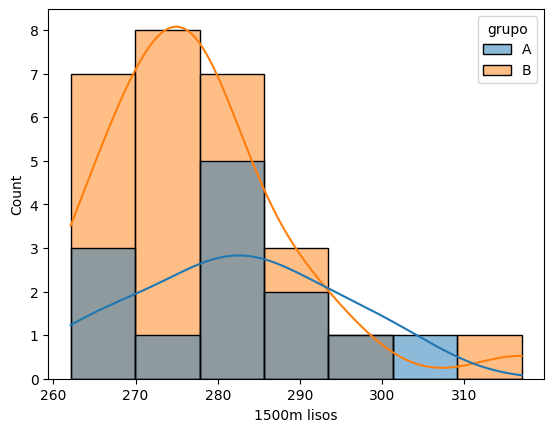

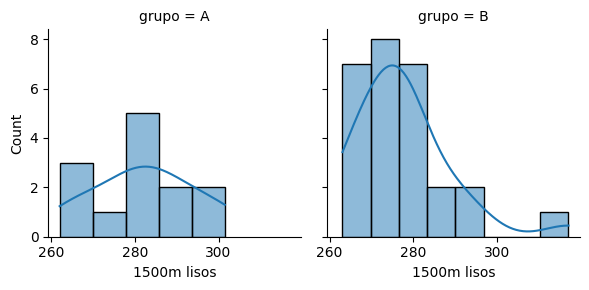


Asimetrias obtenidas para lanzamiento de peso groupby 'grupo' valores: grupo
A   -0.714863
B   -0.199338
Name: lanzamiento de peso, dtype: float64


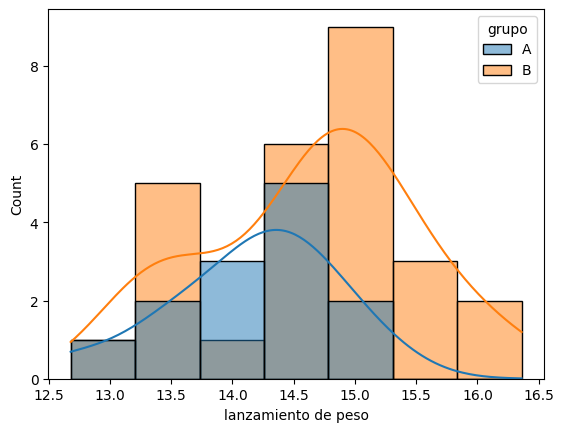

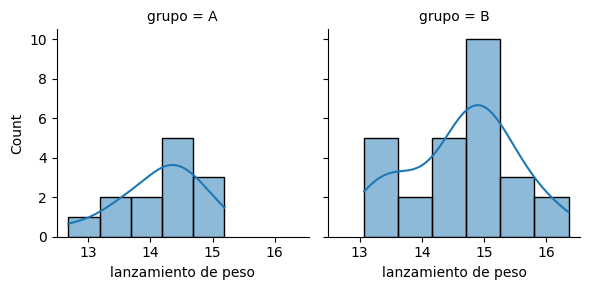


Asimetrias obtenidas para disco groupby 'grupo' valores: grupo
A    0.104323
B    0.417750
Name: disco, dtype: float64


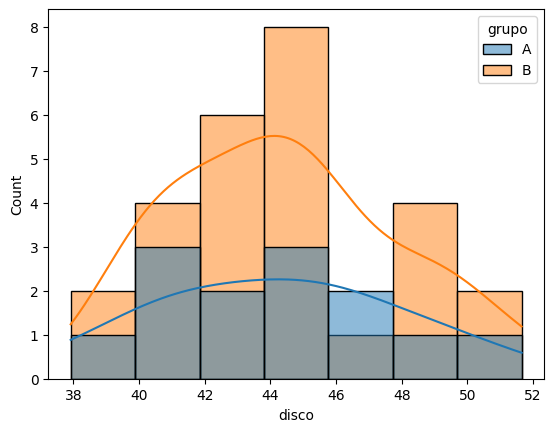

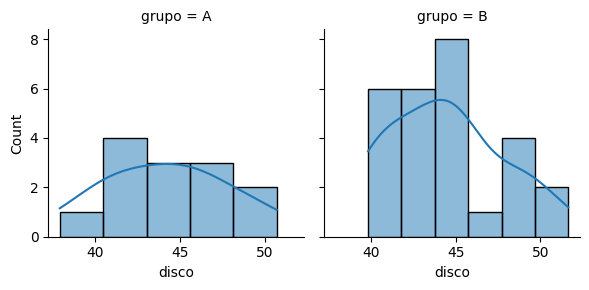


Asimetrias obtenidas para pértiga groupby 'grupo' valores: grupo
A   -0.064995
B    0.527830
Name: pértiga, dtype: float64


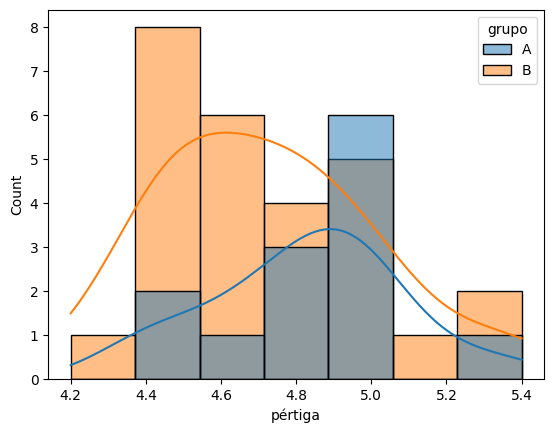

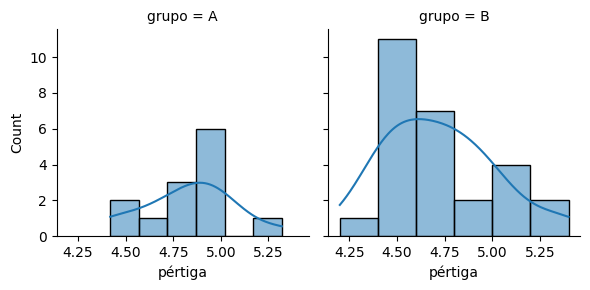


Asimetrias obtenidas para jabalina groupby 'grupo' valores: grupo
A    0.352390
B    0.526326
Name: jabalina, dtype: float64


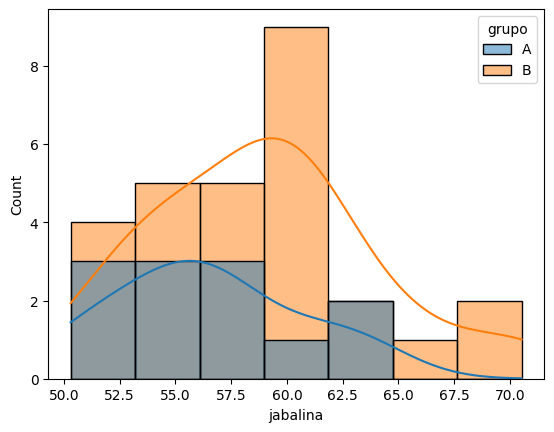

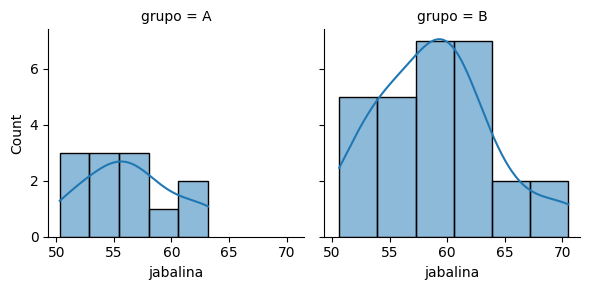

In [12]:
#Usamos la libreria SEABORN y MATPLOTLIB.PYPLOT
import matplotlib.pyplot as plt
import seaborn as sns

# Lo hacemos con todas las columnas recuperadas en columnas_con_nulos
# y como rango BINS en AUTO, para determinar en cuántos rangos se divide
# el histograma agrupando por GRUPO de actividad.
# Ademas del histogrma con los dos Grupos en el mismo gráfico, vamos a usar
# de forma individualizada la función FacetGrid para mostrar tantos histogramas
# como grupos existan en la colummna 'grupo':
for col in columnas_con_nulos:
    sns.histplot(data = df_dataset, x = col, hue='grupo', bins = 'auto', kde = True)
    sns.FacetGrid(df_dataset, col='grupo').map(sns.histplot, col, bins='auto', kde=True)
    skew = df_dataset.groupby('grupo')[col].skew()
    print(f"\nAsimetrias obtenidas para {col} groupby 'grupo' valores: {skew}")
    plt.show()



Con los valores y los histogramas que han resultado podemos determinar que:

GRUPO A:
* 1500m lisos: SIMETRIA -> MEDIA
* lanzamiento de peso: ASIMETRIA negativa -> MEDIANA
* disco: SIMETRIA -> MEDIA
* pértiga: SIMETRIA -> MEDIA
* jabalina: SIMETRIA -> MEDIA

GRUPO B:
* 1500m lisos: ASIMETRIA Positiva -> MEDIANA
* lanzamiento de peso: SIMETRIA -> MEDIA
* disco: SIMETRIA -> MEDIA
* pértiga: LIGERA ASIMETRIA POSITIVA -> MEDIANA
* jabalina: LIGERA ASIMETRIA POSITIVA -> MEDIANA

Con lo que ya podemos ejecutar las siguientes actualizaciones sobre los datos nulos de cada columna, pero vamos a hacerlo con una función que decida segun el valor de skewness:

> Si valor absoluto de **SKEWNESS** > 0,5 --> ASIMETRIA --> **MEDIANA**
>
> Si valor absoluto de **SKEWNESS** < 0,5 --> SIMETRIA  --> **MEDIA**

In [13]:

#Funcion que rellenara de forma automatica los valores no nulos
def f_rellenar_nulos(col, grupo):
    # Calcular skewness, media y mediana por grupo
    skew = df_dataset.groupby('grupo')[col].skew()
    media = df_dataset.groupby('grupo')[col].mean()
    mediana = df_dataset.groupby('grupo')[col].median()

    # Decidir si usar media o mediana
    if abs(skew[grupo]) < 0.5:
        valor = media[grupo].round(2)
        print(f"{col} | Grupo {grupo}: skew={skew[grupo]:.3f} → fillna con MEDIA ({valor:.3f})")
    else:
        valor = mediana[grupo].round(2)
        print(f"{col} | Grupo {grupo}: skew={skew[grupo]:.3f} → fillna con MEDIANA ({valor:.3f})")

    # Imputar SOLO los nulos del grupo usando fillna()
    df_dataset.loc[ (df_dataset['grupo'] == grupo), col] = df_dataset.loc[df_dataset['grupo'] == grupo, col].fillna(valor)

# Por cada grupo tenemos que ejeucutar su asimetria con la funcion
# f_rellenar_nulos
listaGrupos = df_dataset['grupo'].unique()
for col in columnas_con_nulos:
    for grupo in listaGrupos:
        f_rellenar_nulos(col, grupo)

    #f_rellenar_nulos(col, 'A')
    #f_rellenar_nulos(col, 'B')

1500m lisos | Grupo A: skew=-0.014 → fillna con MEDIA (282.200)
1500m lisos | Grupo B: skew=1.635 → fillna con MEDIANA (276.310)
lanzamiento de peso | Grupo A: skew=-0.715 → fillna con MEDIANA (14.260)
lanzamiento de peso | Grupo B: skew=-0.199 → fillna con MEDIA (14.650)
disco | Grupo A: skew=0.104 → fillna con MEDIA (44.220)
disco | Grupo B: skew=0.418 → fillna con MEDIA (44.430)
pértiga | Grupo A: skew=-0.065 → fillna con MEDIA (4.830)
pértiga | Grupo B: skew=0.528 → fillna con MEDIANA (4.700)
jabalina | Grupo A: skew=0.352 → fillna con MEDIA (56.410)
jabalina | Grupo B: skew=0.526 → fillna con MEDIANA (58.940)


In [14]:
print("Valores nulos por columna después de la corrección:")
display(df_dataset.isnull().sum())

if df_dataset.isnull().sum().sum() == 0:
    print("\nCompletada verificación: No se encontraron valores nulos en el Dataset despues de la correción.")
else:
    print("\nAdvertencia: Aún se encontraron valores nulos en el DataSet.")

Valores nulos por columna después de la corrección:


,0
alumno,0
grupo,0
100m lisos,0
400m lisos,0
100m vallas,0
1500m lisos,0
salto horizontal,0
lanzamiento de peso,0
salto de altura,0
disco,0



Completada verificación: No se encontraron valores nulos en el Dataset despues de la correción.


Y pintamos la tabla con todos los valores en formato tabla de nuevo como parte final del **EJERCICIO 1** pero con los valores perdidos calculados y los negativos en positivo con su valor absoluto:

In [15]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

print("Mostrando el DataSet df_dataset como una tabla interactiva con los datos ya tratados sus valores perdidos y los numeros negativos en las marcas erróneas:")
df_dataset

Mostrando el DataSet df_dataset como una tabla interactiva con los datos ya tratados sus valores perdidos y los numeros negativos en las marcas erróneas:


,alumno,grupo,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,Torres,A,11.04,49.81,14.69,291.70,7.58,14.83,2.07,43.75,5.02,63.19
1,Delgado,A,10.76,49.37,14.05,301.50,7.40,14.26,1.86,50.72,4.92,60.15
2,Ramírez,A,11.02,48.37,14.09,300.20,7.30,14.77,2.04,48.95,4.92,50.31
3,Díaz,A,11.02,48.93,14.99,280.10,7.23,14.25,1.92,40.87,5.32,62.77
4,Sánchez,A,11.34,50.42,15.31,276.40,7.09,15.19,2.10,46.26,4.72,56.41
5,Miranda,A,11.11,48.68,14.23,278.10,7.60,14.31,1.98,41.10,4.92,51.77
6,Rodríguez,A,11.13,48.62,14.17,268.00,7.30,13.48,2.01,45.67,4.42,55.37
7,Vargas,A,10.83,49.91,14.38,285.10,7.31,13.76,2.13,44.41,4.42,56.37
8,Castro,A,11.64,50.14,14.93,262.10,6.81,14.57,1.95,47.60,4.92,52.33
9,Pérez,A,11.37,51.10,15.06,285.10,7.56,14.41,1.86,44.99,4.82,57.19


# **PROBLEMA 2: ANALISIS DE COMPONENTES PRINCIPALES**

Análisis de componentes principales y calcular tanto las componentes principales (**autovectores**) como sus inercias (**autovalores**)

## Normalización

Para conseguir estos valores tenesmos que normalizar los vectores que representan cada registro. En el caso que nos ocupa, al mezclar diferentes tipos de medidas como son metros y segundos, no podríamos usar la normalización mediante min-max, así que habrá que normalizar mediante la Estandarización, transformando las variables originales de forma que pasan a ser adimensionales y se elimina la dependencia respecto de las unidades de medidas empleadas mediante **Z-SCORE** o **tipificación**, pasando a ser la media 0 y la desviación típica 1.

Para conseguir esto con nuestros datos vamos a estandarizar, pero solo los atributos cuantitativos, por lo que creaermos un dataset con solo estos atributos y estandarizaremos o normalizaremos con **StandardScaler**.



In [16]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Seleccionar solo los atributos cuantitativos para la estandarización
# performance_columns ya está definido y contiene las columnas correctas
df_quantitative = df_dataset[performance_columns].copy()

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar la estandarización
df_dataset_normalizado = pd.DataFrame(scaler.fit_transform(df_quantitative), columns=performance_columns)

print("DAtaset de atributos cuantitativos estandarizados (Z-SCORE):")
display(df_dataset_normalizado.head())

DAtaset de atributos cuantitativos estandarizados (Z-SCORE):


,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
0,0.161478,0.169981,0.180572,1.102355,1.023937,0.415754,1.060457,-0.183261,0.973290,1.071948
1,-0.916293,-0.216222,-1.192819,1.951816,0.447972,-0.286789,-1.329735,1.909880,0.605842,0.426002
2,0.084494,-1.093956,-1.106982,1.839133,0.127992,0.341802,0.719001,1.378336,0.605842,-1.664826
3,0.084494,-0.602425,0.824348,0.096870,-0.095994,-0.299115,-0.646823,-1.048145,2.075635,0.982706
4,1.316232,0.705398,1.511044,-0.223845,-0.543966,0.859466,1.401913,0.570510,-0.129055,-0.368683


## Reducción de dimensionalidad (2 puntos)

En el ejercicio nos piden directamente hacer una **Análisis de Componentes Principales** para reducir la dimeensionalidad sin hacer una selección de variables mediante filtros de alta correlación o filtros de baja varianza para descartar algún atributo o característica.

Aún asi vamos a explorar qué valores podrían ser correlativos o que atributos tienen bajas varianzas entre si que podrían ayudar mas adelante en el análisis de componentes principales a descartar según los autovalores obtenidos.

### Análisis de Correlación - [SOLO exploración]

Vamos a calcular la matriz de correlación de los atributos cuantitativos estandarizados para identificar posibles relaciones fuertes entre las variables. Una matriz de correlación nos ayudará a visualizar qué variables se mueven juntas y cuáles no. Esto puede ser útil para entender la estructura de los datos antes de la PCA.

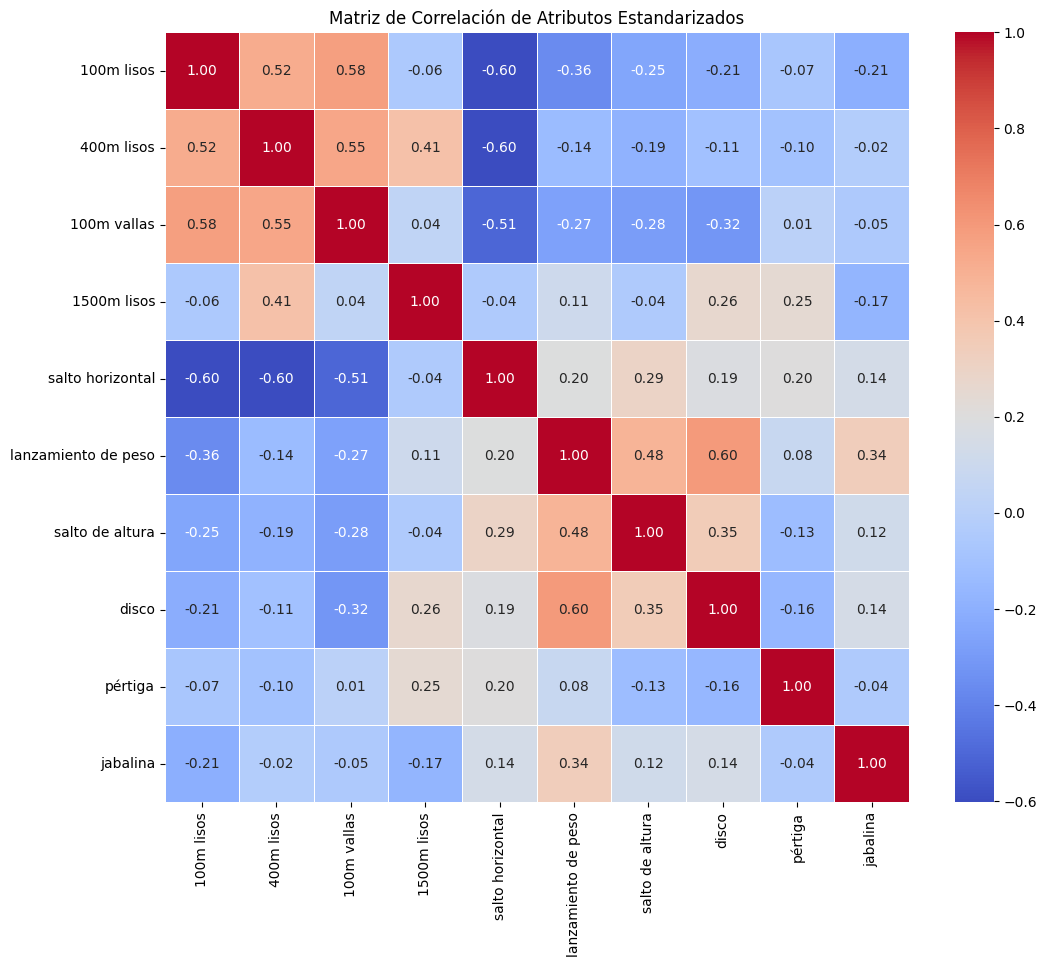

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular la matriz de correlación de los datos escalados
df_matriz_correlacion = df_dataset_normalizado.corr()

# Visualizar la matriz de correlación con un mapa de calor (heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(df_matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Atributos Estandarizados')
plt.show()

Después de ver este análisis de alta correlación podemos observar que tiene una alta correlación:

*   Lanzamiento de peso - disco
*   100m vallas - 100m lisos
*   100m vallas - 400m lisos

Y de igual forma hay valores que nos indican una baja correlación, es decir, que si son buenos en una disciplina lo normal es que sean malos en otra como son:

*   salto horizontal - 100m lisos
*   salto horizontal - 400m lisos






### Análisis de Varianza - [SOLO exploración]

Además del análisis de correlación, podemos realizar un filtro de baja varianza. Las características con muy poca varianza no aportan mucha información al modelo y pueden considerarse para su eliminación.

Calculamos la varianza de cada uno de los atributos cuantitativos pero sin estandarizar, ya que en el dataset normalizado las variables tienen una media de 0 y una desviación estándar de 1 al estar ya normalizadas, por lo que no es valido para su estudio, hay que hacerlo sobre el dataset original filtrado y limpio de datos **df_dataset**.



In [18]:
import numpy as np

# Seleccionar solo los atributos cuantitativos para calcular la varianza
# performance_columns ya está definido y contiene las columnas correctas
df_cols_cuantitativas_varianza = df_dataset[performance_columns].copy()

# Calcular la varianza de cada columna
variances_raw = df_cols_cuantitativas_varianza.var()

print("Varianza de cada atributo cuantitativo en el dataset original:")
display(variances_raw)

# Definir un umbral para la varianza baja (puedes ajustar este valor si es necesario)
umbral_varianza = 0.01
low_variance_features_raw = variances_raw[variances_raw < umbral_varianza].index.tolist()

if low_variance_features_raw:
    print(f"\nAtributos con varianza por debajo de {umbral_varianza} en el dataset original: {low_variance_features_raw}")
else:
    print(f"\nNo se encontraron atributos con varianza por debajo de {umbral_varianza} en el dataset original.")

Varianza de cada atributo cuantitativo en el dataset original:


,0
100m lisos,0.069181
400m lisos,1.330449
100m vallas,0.222585
1500m lisos,136.423359
salto horizontal,0.100110
lanzamiento de peso,0.674725
salto de altura,0.007912
disco,11.365607
pértiga,0.075916
jabalina,22.702701



Atributos con varianza por debajo de 0.01 en el dataset original: ['salto de altura']


Lo que nos lleva a reafirmar un poco lo que hemos visto antes con el **filtro de alta correlación**, y es que los atributos con baja varianza son:
*   100m lisos (atributo candidato en alta correlación)
*   salto de altura
*   pértiga

El atributo 100m lisos se repite en los dos filtros, tanto de alta correlación como de baja varianza, por lo que podría ser un candidato a excluir de los valores y sospechamos que obtendrá un bajo valor o el mas bajo valor en el listado de Autovalores tras calcular los Autovectores. Tambiéns se observa que el Salto de altura tiene una muy baja correlación, por lo que suponemos que también obtendrá un valor en los Autovalores muy bajo.

### **Análisis de Componentes Principales ACP**

Buscar combinaciones lineales de las variables originales que representen lo mejor posible la variabilidad presente en los datos, es decir, que recojan la mayor cantidad de información posible y en este punto poder reducir su dimensionalidad, y como punto final del ejercicio a las 2 dimensiones que se piden.


### Cálculo de las componentes principales

Ya tenemos el DataSet normalizado, por lo que con la ayuda de la librería PCA de sklearn.decomposition vamos a hallar la matriz de los Autovectores y los Autovalores



In [19]:
from sklearn.decomposition import PCA

#Ya tenemos el dataset con los datos normalizados: df_dataset_normalizado
pca = PCA()
pca_data = pca.fit_transform(df_dataset_normalizado)

# Crear un Dataset para visualizar los autovectores con los nombres de las columnas
df_autovectores = pd.DataFrame(
    pca.components_.round(3),
    columns= performance_columns,
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

print('Matriz de Autovectores (Componentes Principales):')
for i in range(len(pca.components_)):
  print(f'u{i+1} = {np.round(pca.components_[i],3)}')

print("\nAutovectores (Componentes Principales) con la contribución de cada atributo original:")
display(df_autovectores)

print('\nAutovalores (INERCIAS):')
for i in range(len(pca.explained_variance_)):
  print(f'λ{i+1} = {np.round(pca.explained_variance_[i],3)}')

Matriz de Autovectores (Componentes Principales):
u1 = [ 0.431  0.378  0.416  0.039 -0.413 -0.342 -0.309 -0.291 -0.03  -0.166]
u2 = [ 0.119  0.439  0.141  0.427 -0.243  0.443  0.251  0.487 -0.107  0.153]
u3 = [-0.155  0.053 -0.061  0.611  0.191 -0.048 -0.219 -0.035  0.638 -0.317]
u4 = [-0.047  0.072  0.279 -0.143  0.051  0.21  -0.152 -0.231  0.456  0.751]
u5 = [ 0.347 -0.124  0.241 -0.26   0.014  0.212  0.625 -0.126  0.42  -0.333]
u6 = [-0.278  0.335  0.093  0.276  0.274 -0.29   0.526 -0.467 -0.233  0.135]
u7 = [ 0.337 -0.12   0.419  0.07   0.635 -0.306 -0.053  0.415 -0.091  0.104]
u8 = [-0.525 -0.162  0.671 -0.034 -0.002  0.314 -0.155 -0.048 -0.193 -0.291]
u9 = [ 0.178  0.485 -0.179 -0.225  0.502  0.461 -0.27  -0.221 -0.128 -0.219]
u10 = [-0.394  0.503  0.018 -0.471 -0.016 -0.327  0.059  0.408  0.283 -0.111]

Autovectores (Componentes Principales) con la contribución de cada atributo original:


,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
PC1,0.431,0.378,0.416,0.039,-0.413,-0.342,-0.309,-0.291,-0.030,-0.166
PC2,0.119,0.439,0.141,0.427,-0.243,0.443,0.251,0.487,-0.107,0.153
PC3,-0.155,0.053,-0.061,0.611,0.191,-0.048,-0.219,-0.035,0.638,-0.317
PC4,-0.047,0.072,0.279,-0.143,0.051,0.210,-0.152,-0.231,0.456,0.751
PC5,0.347,-0.124,0.241,-0.260,0.014,0.212,0.625,-0.126,0.420,-0.333
PC6,-0.278,0.335,0.093,0.276,0.274,-0.290,0.526,-0.467,-0.233,0.135
PC7,0.337,-0.120,0.419,0.070,0.635,-0.306,-0.053,0.415,-0.091,0.104
PC8,-0.525,-0.162,0.671,-0.034,-0.002,0.314,-0.155,-0.048,-0.193,-0.291
PC9,0.178,0.485,-0.179,-0.225,0.502,0.461,-0.270,-0.221,-0.128,-0.219
PC10,-0.394,0.503,0.018,-0.471,-0.016,-0.327,0.059,0.408,0.283,-0.111



Autovalores (INERCIAS):
λ1 = 3.356
λ2 = 1.747
λ3 = 1.409
λ4 = 1.064
λ5 = 0.777
λ6 = 0.612
λ7 = 0.465
λ8 = 0.403
λ9 = 0.238
λ10 = 0.179


### Interpretación de Autovectores y Autovalores

Los **autovectores** son los Componentes Principales en sí mismos. Cada autovector es un vector de coeficientes que indica cómo se combinan las variables originales para formar esa componente principal. Los valores dentro de cada autovector, también llamados `pesos`, `cargas` indican la importancia y dirección de la contribución de cada variable original a esa componente.

Cuanto mas alto sea el peso del atributo, significa que un valor alto de ese atributo contribuye a un valor alto de la PC1.

Los Autovecotres principales para representar en 2 dimensiones serán PC1 y PC2, pero si qusiéramos tener una gran representatividad del conjunto, nos deberíamos quedar con al menos los 5 primeros autovectores porque forman mas del 80% de la inercia acumulada.



## Dibujar **Scree Plot** (1 punto)

Los autovalores ( λ ) se presentan en orden descendente y representan la cantidad de varianza explicada por cada componente principal (PC).

Un autovalor más grande significa que su componente principal asociada captura más información (variabilidad) del conjunto de datos original.

Para entender mejor su reparto se grafica un Scree Plot para reprenentar su representatividad y observar donde comienza el codo de la gráfica, esto es, dónde la caida es acusada y despues continua decreciendo. Se observa que PC1 y PC2 capturan la mayor parte de la estructura global del dataset y partir de ahí la cantidad de información será menos importante en comparación con el peso del resto.

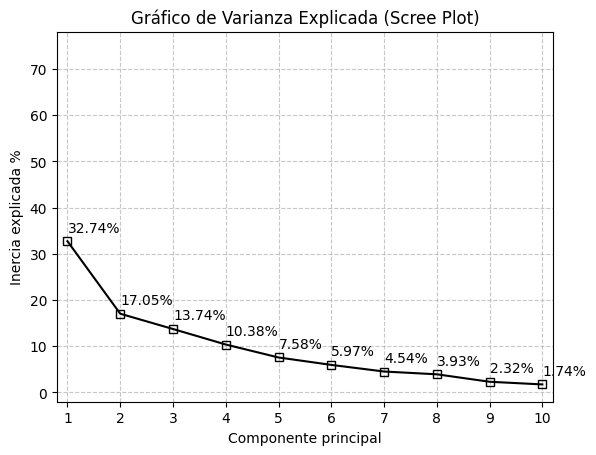

In [20]:
import matplotlib.pyplot as plt

plt.plot(np.arange(pca.n_components_) + 1, 100*pca.explained_variance_ratio_, marker = 's', markerfacecolor = 'None', markeredgecolor = 'black', c = 'black')

for i in range(len(pca.components_)):
  inercia_exp = round(100*pca.explained_variance_ratio_[i],2)
  plt.text(i+1,inercia_exp+2,str(inercia_exp)+'%')

plt.xticks(np.arange(pca.n_components_) + 1) # Ensure x-ticks align with components
plt.ylim(-2,78) # Adjust y-axis limits to accommodate labels and data
plt.xlim(0.8,pca.n_components_ + 0.2) # Adjust x-axis limits to fit all components
plt.ylabel('Inercia explicada %') # Set clear y-axis label
plt.xlabel('Componente principal') # Set clear x-axis label
plt.title('Gráfico de Varianza Explicada (Scree Plot)') # Add a title for clarity
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.show()

## **Representación sobre las dos primeras Componentes Principales** (2 puntos)

Ya tenemos la matriz de Autovectores en el dataset `df_autovectores` por lo que tendremos que crear una segunda matriz con solo los 2 primeros vectores para proyectar los datos de los atletas y obtener asi los resultados de forma gráfica en 2 dimensiones.

Esto se consigue multiplicado la matriz formada por los dos autovectores principales x la matriz traspuesta de la matriz df_dataset que contiene los atributos normalizados:

In [23]:
import numpy as np

# Seleccionar los dos primeros autovectores (PC1 y PC2)
# df_autovectores tiene la forma (n_components, n_features)
# Donde n_components es 10 y n_features es 10.
# PC1 es la primera fila (indice 0) y PC2 es la segunda fila (indice 1)
autovectores_2d = df_autovectores.iloc[0:2, :]

print("\nMatriz con solo los vectores PC1 y PC2:")
display(autovectores_2d)

# Convertir el DataFrame normalizado a un array de NumPy para la multiplicación
# Es importante usar df_dataset_normalizado ya que la PCA se aplicó sobre él.
df_normalizado_np = df_dataset_normalizado.to_numpy()

# Realizar la proyección multiplicando la matriz de datos normalizados
# por la traspuesta de la matriz de autovectores_2d, ya que tenemos los autovectores como
# filas y no como columnas:
# (n_samples, n_features) @ (n_features, n_components) = (n_samples, n_components)
projected_data = np.dot(df_normalizado_np, autovectores_2d.T)

# Crear un DataFrame con los datos proyectados
df_proyeccion_atletas_2d = pd.DataFrame(data=projected_data, columns=['PC1', 'PC2'])

# Añadir las columnas 'alumno' y 'grupo' del dataset original para identificar los puntos
df_proyeccion_atletas_2d['alumno'] = df_dataset['alumno']
df_proyeccion_atletas_2d['grupo'] = df_dataset['grupo']

print("Datos proyectados en las dos primeras Componentes Principales (PC1 y PC2):")
display(df_proyeccion_atletas_2d.head())
display(df_proyeccion_atletas_2d.tail())


Matriz con solo los vectores PC1 y PC2:


,100m lisos,400m lisos,100m vallas,1500m lisos,salto horizontal,lanzamiento de peso,salto de altura,disco,pértiga,jabalina
PC1,0.431,0.378,0.416,0.039,-0.413,-0.342,-0.309,-0.291,-0.030,-0.166
PC2,0.119,0.439,0.141,0.427,-0.243,0.443,0.251,0.487,-0.107,0.153


Datos proyectados en las dos primeras Componentes Principales (PC1 y PC2):


,PC1,PC2,alumno,grupo
0,-0.794609,0.762159,Torres,A
1,-1.217455,0.822074,Delgado,A
2,-1.300715,0.811525,Ramírez,A
3,0.576830,-0.950533,Díaz,A
4,0.850385,1.683823,Sánchez,A


,PC1,PC2,alumno,grupo
36,2.383610,-1.790742,Figueroa,B
37,2.018455,-0.279898,Aguilar,B
38,1.011041,2.367708,Montes,B
39,2.433944,0.359992,Morales,B
40,2.909946,3.781213,Jiménez,B


Representación gráfica en 2D de la matriz de Atletas de los dos grupo A y B:

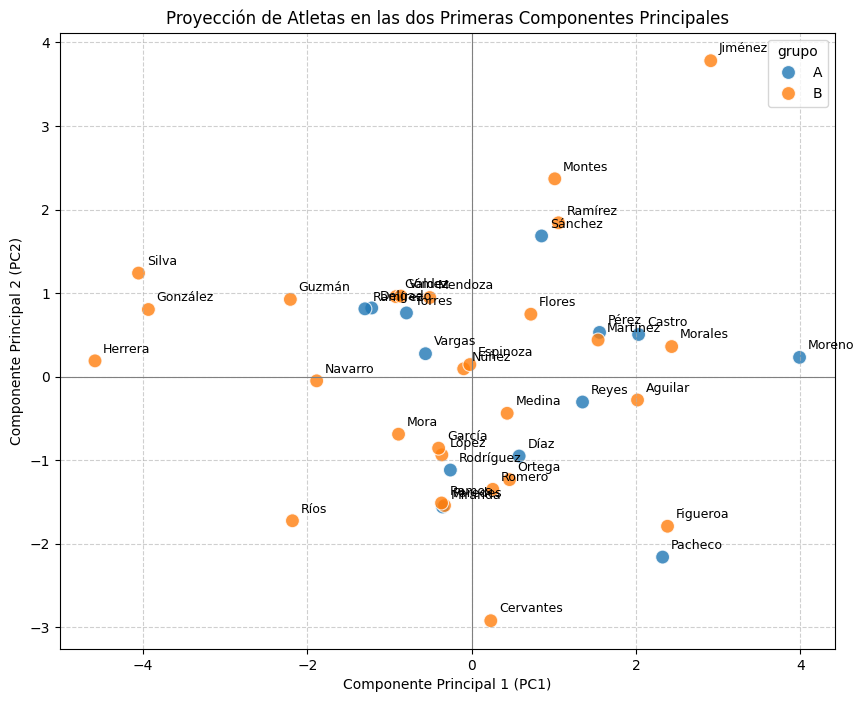

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='grupo', data=df_proyeccion_atletas_2d, s=100, alpha=0.8)

for i, row in df_proyeccion_atletas_2d.iterrows():
    plt.text(row['PC1'] + 0.1, row['PC2'] + 0.1, row['alumno'], fontsize=9)

plt.title('Proyección de Atletas en las dos Primeras Componentes Principales')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)
plt.show()

**SOLUCIÓN**: Según esta representación, los valoresas cercanos a Pacheco son los de el atleta **Figueroa** del grupo B

## **Calcular Ranking TOP 3** (2 puntos)

Es bastante similar al anterior punto, solo que en este caso para hallar el top 3 y el ranking total para ver en una dimensión los resultados de los atletas, se debe calcular la proyección de la matriz normalizada únicamente sobre el vector del primer componente principal, es decir el PC1, multiplicando la matriz matriz normalizada de los resultados con el vector PC1

In [25]:
import numpy as np

# Seleccionar solo el primer autovector (PC1)
# df_autovectores tiene la forma (n_components, n_features)
# PC1 es la primera fila (indice 0)
autovector_pc1 = df_autovectores.iloc[0, :]

print("\nVector PC1:")
display(autovector_pc1)

# Convertir el DataFrame normalizado a un array de NumPy para la multiplicación
df_normalizado_np = df_dataset_normalizado.to_numpy()

# Realizar la proyección multiplicando la matriz de datos normalizados
# por el vector PC1
# (n_samples, n_features) @ (n_features,) = (n_samples,)
projected_data_pc1 = np.dot(df_normalizado_np, autovector_pc1)

# Crear un DataFrame con los datos proyectados
df_ranking = pd.DataFrame(data=projected_data_pc1, columns=['PC1_Score'])

# Añadir las columnas 'alumno' y 'grupo' del dataset original para identificar los puntos
df_ranking['alumno'] = df_dataset['alumno']
df_ranking['grupo'] = df_dataset['grupo']

# Ordenar el ranking por la puntuación de PC1 (asumiendo que un valor más alto es mejor rendimiento)
df_ranking_sorted = df_ranking.sort_values(by='PC1_Score', ascending=False).reset_index(drop=True)

print("\nRanking completo de atletas basado en PC1:")
display(df_ranking_sorted)

print("\nTOP 3 atletas:")
display(df_ranking_sorted.head(3))


Vector PC1:


,PC1
100m lisos,0.431
400m lisos,0.378
100m vallas,0.416
1500m lisos,0.039
salto horizontal,-0.413
lanzamiento de peso,-0.342
salto de altura,-0.309
disco,-0.291
pértiga,-0.030
jabalina,-0.166



Ranking completo de atletas basado en PC1:


,PC1_Score,alumno,grupo
0,3.990927,Moreno,A
1,2.909946,Jiménez,B
2,2.433944,Morales,B
3,2.383610,Figueroa,B
4,2.323754,Pacheco,A
5,2.031298,Castro,A
6,2.018455,Aguilar,B
7,1.556207,Pérez,A
8,1.538052,Martínez,B
9,1.348880,Reyes,A



TOP 3 atletas:


,PC1_Score,alumno,grupo
0,3.990927,Moreno,A
1,2.909946,Jiménez,B
2,2.433944,Morales,B
